In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

In [4]:
# 1. LOAD DATA
df = pd.read_csv("RoadAccidentData1.csv")
df.columns = df.columns.str.strip()
df.head(5)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307973 entries, 0 to 307972
Data columns (total 21 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Accident_Index              307973 non-null  object 
 1   Accident Date               307973 non-null  object 
 2   Day_of_Week                 307973 non-null  object 
 3   Junction_Control            307973 non-null  object 
 4   Junction_Detail             307973 non-null  object 
 5   Accident_Severity           307973 non-null  object 
 6   Latitude                    307973 non-null  float64
 7   Light_Conditions            307973 non-null  object 
 8   Local_Authority_(District)  307973 non-null  object 
 9   Carriageway_Hazards         5424 non-null    object 
 10  Longitude                   307973 non-null  float64
 11  Number_of_Casualties        307973 non-null  int64  
 12  Number_of_Vehicles          307973 non-null  int64  
 13  Police_Force  

In [5]:
# Fix Accident_Severity — handles text or numeric
severity_map = {"Fatal": 1, "Serious": 2, "Slight": 3}
df["Accident_Severity"] = df["Accident_Severity"].replace(severity_map)
df["Accident_Severity"] = pd.to_numeric(df["Accident_Severity"], errors="coerce")
df = df.dropna(subset=["Accident_Severity"])
df["Accident_Severity"] = df["Accident_Severity"].astype(int)

print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df["Accident_Severity"].value_counts().sort_index()
      .rename({1: "Fatal", 2: "Serious", 3: "Slight"}))


Dataset shape: (307973, 21)

Class distribution:
Accident_Severity
Fatal        3953
Serious     40740
Slight     263280
Name: count, dtype: int64


In [6]:
# 2. SELECT FEATURES
FEATURES = [
    "Weather_Conditions",
    "Road_Type",
    "Light_Conditions",
    "Speed_limit",
    "Road_Surface_Conditions",
    "Urban_or_Rural_Area",
    "Number_of_Vehicles",
    "Junction_Detail",
]
FEATURES = [f for f in FEATURES if f in df.columns]
df = df[FEATURES + ["Accident_Severity"]].dropna()
print("\nFeatures used:", FEATURES)
print("Rows after dropna:", len(df))


Features used: ['Weather_Conditions', 'Road_Type', 'Light_Conditions', 'Speed_limit', 'Road_Surface_Conditions', 'Urban_or_Rural_Area', 'Number_of_Vehicles', 'Junction_Detail']
Rows after dropna: 300512


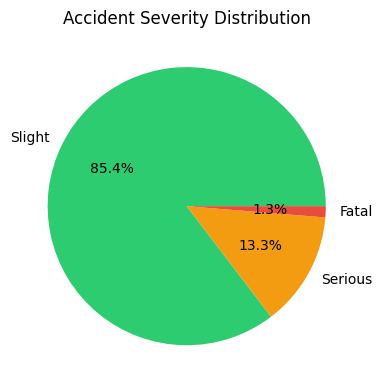

In [7]:
# 3. EDA PLOTS
severity_counts = df["Accident_Severity"].value_counts()
plt.figure(figsize=(4, 4))
plt.pie(severity_counts,
        labels=["Slight","Serious","Fatal"],
        autopct="%1.1f%%",
        colors=["#2ecc71","#f39c12","#e74c3c"])
plt.title("Accident Severity Distribution")
plt.tight_layout(); plt.show()


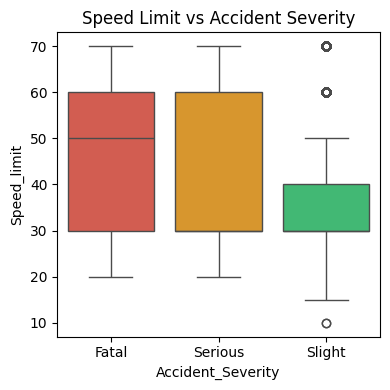

In [8]:
plt.figure(figsize=(4, 4))
sns.boxplot(x="Accident_Severity", y="Speed_limit", data=df,
            palette=["#e74c3c","#f39c12","#2ecc71"])
plt.xticks([0,1,2], ["Fatal","Serious","Slight"])
plt.title("Speed Limit vs Accident Severity")
plt.tight_layout(); plt.show()

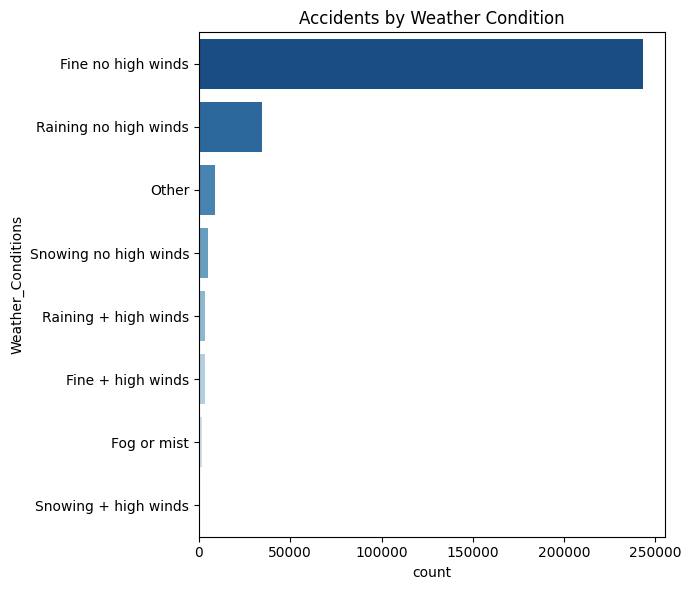

In [9]:
plt.figure(figsize=(7, 6))
sns.countplot(y="Weather_Conditions", data=df,
              order=df["Weather_Conditions"].value_counts().index,
              palette="Blues_r")
plt.title("Accidents by Weather Condition")
plt.tight_layout(); plt.show()

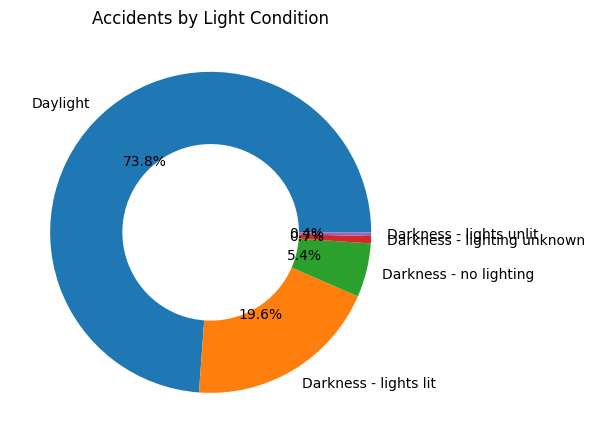

In [10]:
light_counts = df["Light_Conditions"].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(light_counts, labels=light_counts.index,
        autopct="%1.1f%%", wedgeprops=dict(width=0.45))
plt.title("Accidents by Light Condition")
plt.tight_layout(); plt.show()

In [11]:
# 4. ENCODE

cat_cols = [c for c in FEATURES if df[c].dtype == object]
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

joblib.dump(encoders, "encoders.pkl")
joblib.dump(FEATURES, "feature_list.pkl")
print("\nEncoders and feature list saved.")


Encoders and feature list saved.


In [12]:
# 5. SPLIT + SMOTE (Synthetic Minority Oversampling Technique)

X = df[FEATURES]
y = df["Accident_Severity"] - 1    

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_bal).value_counts().sort_index()
      .rename({0:"Fatal",1:"Serious",2:"Slight"}))


After SMOTE:
Accident_Severity
Fatal      205227
Serious    205227
Slight     205227
Name: count, dtype: int64


In [13]:
# 6. TRAIN XGBOOST

model = XGBClassifier(
    n_estimators      = 300,
    max_depth         = 6,
    learning_rate     = 0.1,
    use_label_encoder = False,
    eval_metric       = "mlogloss",
    random_state      = 42,
    n_jobs            = -1,
)
model.fit(X_train_bal, y_train_bal)
print("Training complete.")


Training complete.



=== Classification Report ===
              precision    recall  f1-score   support

       Fatal       0.03      0.53      0.06       779
     Serious       0.18      0.29      0.22      8017
      Slight       0.90      0.60      0.72     51307

    accuracy                           0.56     60103
   macro avg       0.37      0.47      0.33     60103
weighted avg       0.79      0.56      0.64     60103



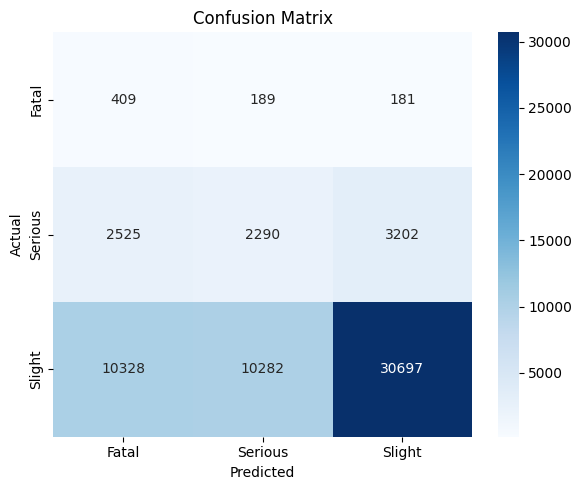

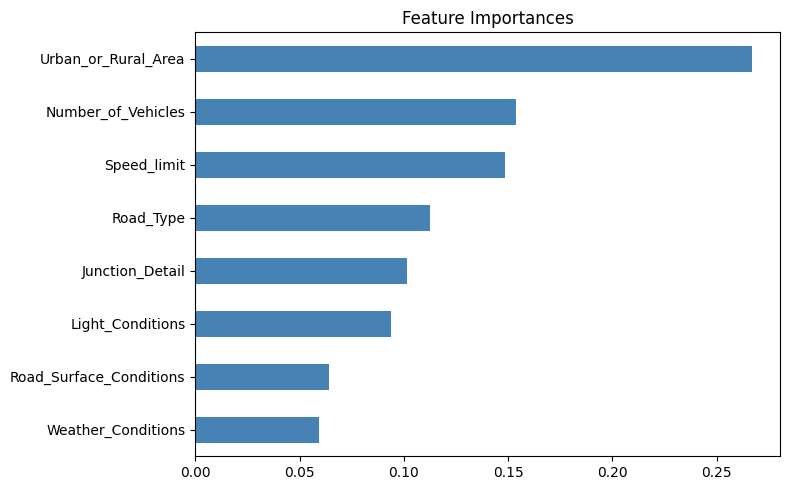

In [14]:
# 7. EVALUATE

pred = model.predict(X_test)
print("\n=== Classification Report ===")
print(classification_report(y_test, pred,
                             target_names=["Fatal","Serious","Slight"]))

cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fatal","Serious","Slight"],
            yticklabels=["Fatal","Serious","Slight"])
plt.title("Confusion Matrix")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout(); plt.show()

feat_imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
plt.figure(figsize=(8, 5))
feat_imp.plot(kind="barh", color="steelblue")
plt.title("Feature Importances")
plt.tight_layout(); plt.show()


In [15]:
# 8. SAVE

joblib.dump(model, "accident_model.pkl")
print("Model saved.")


Model saved.


In [16]:
# 9. SANITY CHECK

print("\n=== Sanity Check ===")
label_map = {0:"Fatal", 1:"Serious", 2:"Slight"}

SLIGHT_THRESHOLD = 0.28

def predict_case(inputs_dict):
    row = {}
    for feat in FEATURES:
        val = inputs_dict.get(feat, None)
        if val is None:
            row[feat] = 0
        elif feat in encoders:
            row[feat] = encoders[feat].transform([str(val)])[0]
        else:
            row[feat] = val
    X    = pd.DataFrame([row])[FEATURES]
    prob = model.predict_proba(X)[0]
    
   
    if prob[2] >= SLIGHT_THRESHOLD and prob[2] >= prob[0]:
        p = 2
    else:
        p = int(np.argmax(prob))
    return label_map[p], prob


tests = [
    {
        "desc": "Fine weather + Daylight + 30mph + Dry + Urban + 1 vehicle + No junction → SLIGHT",
        "Weather_Conditions":      "Fine no high winds",
        "Road_Type":               "Single carriageway",
        "Light_Conditions":        "Daylight",
        "Speed_limit":             30,
        "Road_Surface_Conditions": "Dry",
        "Urban_or_Rural_Area":     "Urban",
        "Number_of_Vehicles":      1,
        "Junction_Detail":         "Not at junction or within 20 metres",
    },
    {
        "desc": "Fog + No lighting + 70mph + Wet + Rural + 2 vehicles → FATAL/SERIOUS",
        "Weather_Conditions":      "Fog or mist",
        "Road_Type":               "Dual carriageway",
        "Light_Conditions":        "Darkness - no lighting",
        "Speed_limit":             70,
        "Road_Surface_Conditions": "Wet or damp",
        "Urban_or_Rural_Area":     "Rural",
        "Number_of_Vehicles":      2,
        "Junction_Detail":         "Not at junction or within 20 metres",
    },
    {
        "desc": "Snow+wind + No lighting + 60mph + Icy + Rural + 2 vehicles → FATAL",
        "Weather_Conditions":      "Snowing + high winds",
        "Road_Type":               "Single carriageway",
        "Light_Conditions":        "Darkness - no lighting",
        "Speed_limit":             60,
        "Road_Surface_Conditions": "Frost or ice",
        "Urban_or_Rural_Area":     "Rural",
        "Number_of_Vehicles":      2,
        "Junction_Detail":         "Not at junction or within 20 metres",
    },
]

for tc in tests:
    sev, prob = predict_case(tc)
    print(f"\n  {tc['desc']}")
    print(f"  → {sev}  | Fatal {prob[0]*100:.1f}%  Serious {prob[1]*100:.1f}%  Slight {prob[2]*100:.1f}%")

print("\nDone! Run:  python -m streamlit run app.py")


=== Sanity Check ===

  Fine weather + Daylight + 30mph + Dry + Urban + 1 vehicle + No junction → SLIGHT
  → Slight  | Fatal 24.5%  Serious 44.3%  Slight 31.3%

  Fog + No lighting + 70mph + Wet + Rural + 2 vehicles → FATAL/SERIOUS
  → Fatal  | Fatal 50.7%  Serious 24.9%  Slight 24.4%

  Snow+wind + No lighting + 60mph + Icy + Rural + 2 vehicles → FATAL
  → Fatal  | Fatal 42.5%  Serious 27.9%  Slight 29.6%

Done! Run:  python -m streamlit run app.py
